In [ ]:
import os, shutil, random, pathlib

# 경로 설정
IMG_ROOT = pathlib.Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/1. 원본")   # 이미지 최상위 경로
LBL_ROOT = pathlib.Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/3. labeled(segmentation)")  # 라벨 최상위 경로 (txt가 들어있는 곳)
SPLIT_ROOT = pathlib.Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/250907_dataset_split") # 분할된 데이터셋을 저장할 새로운 최상위 경로

# 분할 비율 설정
splits = {"train":0.7, "val":0.2, "test":0.1}

# Check if SPLIT_ROOT is within IMG_ROOT or LBL_ROOT
if SPLIT_ROOT.is_relative_to(IMG_ROOT) or SPLIT_ROOT.is_relative_to(LBL_ROOT):
    print("Error: SPLIT_ROOT should not be inside IMG_ROOT or LBL_ROOT.")
    print(f"IMG_ROOT: {IMG_ROOT}")
    print(f"LBL_ROOT: {LBL_ROOT}")
    print(f"SPLIT_ROOT: {SPLIT_ROOT}")
else:
    # 모든 이미지 수집 (하위폴더 포함)
    # Only collect images that have a corresponding label file
    imgs = []
    for img_path in IMG_ROOT.rglob("*.*"):  # Search for any file extension
        # Construct the potential label path by replacing the image root and changing the suffix to .txt
        # Also, make sure to match by stem (filename without extension)
        label_path_candidate = LBL_ROOT / img_path.relative_to(IMG_ROOT).with_suffix(".txt")
        # Check if a label file with the same stem exists in the label root
        if (LBL_ROOT / label_path_candidate.parent / img_path.stem).with_suffix(".txt").exists():
            imgs.append(img_path)

    random.seed(0); random.shuffle(imgs)

    n = len(imgs)
    cut1 = int(n*splits["train"])
    cut2 = int(n*(splits["train"]+splits["val"]))
    parts = {"train": imgs[:cut1], "val": imgs[cut1:cut2], "test": imgs[cut2:]}

    # 분할된 데이터셋 저장 폴더 생성
    os.makedirs(SPLIT_ROOT, exist_ok=True)

    for split, files in parts.items():
        # Check if files list is empty to avoid IndexError
        if not files:
            print(f"Warning: No files found for split: {split}")
            continue

        for img in files:
            # 복사 대상 폴더 경로 생성 (예: /content/drive/.../dataset_split/train/images/250811)
            img_dest_folder = SPLIT_ROOT / split / "images" / img.parent.relative_to(IMG_ROOT)
            lbl_dest_folder = SPLIT_ROOT / split / "labels" / img.parent.relative_to(IMG_ROOT)

            # 대상 폴더가 없으면 생성
            os.makedirs(img_dest_folder, exist_ok=True)
            os.makedirs(lbl_dest_folder, exist_ok=True)

            # 파일 복사
            shutil.copy2(str(img), str(img_dest_folder / img.name))
            # Find the corresponding label file based on the image's stem
            lbl_match = (LBL_ROOT / img.relative_to(IMG_ROOT).parent / img.stem).with_suffix(".txt")
            if lbl_match.exists():
                shutil.copy2(str(lbl_match), str(lbl_dest_folder / lbl_match.name))
            else:
                print(f"Warning: Label file not found for image: {img}")


    print("done")

done


yolov8 segmentation 파일 준비

In [1]:
### YOLOv8 Colab 학습 전체 코드
# 1. Ultralytics 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.6 MB/s eta 0:00:00


In [3]:


# 3. 데이터셋 경로 지정 (네 Drive 안 dataset 폴더)
DATASET_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/250907_dataset_split"
DATA_YAML = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/data_seg.yaml"
print("Using data.yaml:", DATA_YAML)

# 4. YOLO 불러오기
from ultralytics import YOLO

# Pretrained YOLOv8n (자동 다운로드)
model = YOLO("yolov8n-seg.pt")  # 혹은 "yolov8n.yaml"으로 랜덤 초기화

Using data.yaml: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/data_seg.yaml


Ultralytics 8.3.195 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/data_seg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=lettuce_yolov8n4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

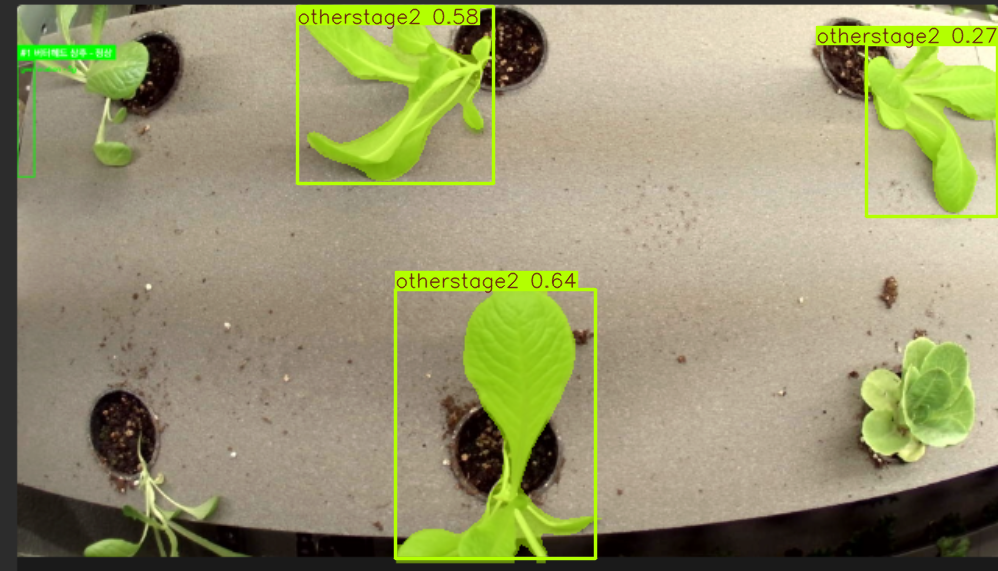

In [4]:

# 5. 학습 시작
model.train(
    data=DATA_YAML,   # data.yaml 경로
    task="segment",
    epochs=50,        # 반복 학습 횟수
    imgsz=640,        # 입력 이미지 크기
    batch=16,         # 배치 크기
    workers=2,        # 병렬 데이터로더 수 (Colab CPU 따라 조정)
    project="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/results/250908 segmentation",  # 결과 저장 폴더
    name="lettuce_yolov8n"                           # 결과 하위 이름
)

# 6. 학습 결과 확인 (mAP, loss 등)
results = model.val()
print(results)

# 7. 추론 테스트 (임의의 이미지 한 장)
TEST_IMG = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/1. 원본/250811/20250811_001852.png"
preds = model.predict(TEST_IMG, save=False, conf=0.25) # save=False로 설정하여 저장하지 않음

# 8. 결과 확인
from IPython.display import Image
# preds[0].plot() 함수를 사용하여 결과 이미지를 얻고, 이를 PIL Image로 변환 후 표시
from PIL import Image as PIL_Image
import numpy as np

result_img = preds[0].plot(img=np.array(PIL_Image.open(TEST_IMG)))
display(PIL_Image.fromarray(result_img))


In [5]:
import os
from ultralytics import YOLO
import numpy as np
from PIL import Image as PIL_Image

# 모델 로드
model = YOLO("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/results/250908 segmentation/lettuce_yolov8n3/weights/best.pt")

# 이미지 폴더 경로
IMG_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/250907_dataset_split/train/images/250811/"

# 경로 안 모든 이미지 순회
for img_file in os.listdir(IMG_DIR):
    if img_file.lower().endswith((".png", ".jpg", ".jpeg")):
        img_path = os.path.join(IMG_DIR, img_file)
        results = model.predict(img_path, conf=0.05, task="segment", verbose=False)

        print(f"Image: {img_file}")
        for r in results:
            if r.masks is not None:
                for i, mask in enumerate(r.masks.data):
                    mask_np = mask.cpu().numpy().astype(np.uint8)
                    area_px = mask_np.sum()
                    print(f"  Mask {i+1} 면적(px²): {area_px}")
            else:
                print("  No detections")


Image: 20250811_001806.png
  Mask 1 면적(px²): 14555
  Mask 2 면적(px²): 3837
Image: 20250811_001852.png
  Mask 1 면적(px²): 8864
  Mask 2 면적(px²): 6335
  Mask 3 면적(px²): 4658
  Mask 4 면적(px²): 4859
Image: 20250811_002245_7.png
  Mask 1 면적(px²): 11307
  Mask 2 면적(px²): 10704
  Mask 3 면적(px²): 8342
  Mask 4 면적(px²): 14557
  Mask 5 면적(px²): 6536
  Mask 6 면적(px²): 10533
Image: 20250811_002245_13.png
  Mask 1 면적(px²): 15904
  Mask 2 면적(px²): 20809
  Mask 3 면적(px²): 12629
  Mask 4 면적(px²): 5542
  Mask 5 면적(px²): 7243
  Mask 6 면적(px²): 16236
Image: 20250811_002245_1.png
  Mask 1 면적(px²): 3924
  Mask 2 면적(px²): 1353
  Mask 3 면적(px²): 1179
Image: 20250811_002245_14.png
  Mask 1 면적(px²): 8072
  Mask 2 면적(px²): 8145
  Mask 3 면적(px²): 8924
  Mask 4 면적(px²): 10832
  Mask 5 면적(px²): 14973
  Mask 6 면적(px²): 9517
Image: 20250811_002245_8.png
  Mask 1 면적(px²): 12439
  Mask 2 면적(px²): 17190
  Mask 3 면적(px²): 35106
  Mask 4 면적(px²): 22745
  Mask 5 면적(px²): 19126
  Mask 6 면적(px²): 16236
Image: 20250811_002245_

면적 정확히 따기

In [ ]:
IMG_ROOT = pathlib.Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/1. 원본")   # 이미지 최상위 경로
LBL_ROOT = pathlib.Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/3. labeled(segmentation)")  # 라벨 최상위 경로 (txt가 들어있는 곳)

In [8]:
import os, glob
import numpy as np
import cv2

IMG_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/250907_dataset_split/train/images/250811"        # 이미지 루트
LBL_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/250907_dataset_split/train/labels/250811"        # 라벨 루트 (동일 파일명 .txt)
H, W = 998, 571                    # 각 이미지 해상도(정확히 넣기!)  # 중요

def yolo_poly_to_pixels(vals):
    # vals: [cls, x1,y1,x2,y2,...] (0~1 정규화)
    xy = np.array(vals[1:], dtype=float).reshape(-1,2)
    xy[:,0] *= W
    xy[:,1] *= H
    return xy.astype(np.float32)

for img_path in sorted(glob.glob(os.path.join(IMG_DIR, "*.png"))):
    name = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(LBL_DIR, name + ".txt")
    print("Image:", name + ".png")
    if not os.path.exists(lbl_path):
        print("  (no label)")
        continue
    with open(lbl_path, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        print("  (empty label)")
        continue
    for i, line in enumerate(lines, 1):
        vals = line.split()
        poly = yolo_poly_to_pixels(vals)
        area_px = cv2.contourArea(poly)
        print(f"  GT Mask {i} 면적(px²): {int(area_px)}")


Image: 20250811_001806.png
  GT Mask 1 면적(px²): 9201
  GT Mask 2 면적(px²): 34026
  GT Mask 3 면적(px²): 4876
Image: 20250811_001852.png
  GT Mask 1 면적(px²): 21230
  GT Mask 2 면적(px²): 13162
Image: 20250811_002245_1.png
  GT Mask 1 면적(px²): 2174
  GT Mask 2 면적(px²): 8349
  GT Mask 3 면적(px²): 2355
Image: 20250811_002245_10.png
  GT Mask 1 면적(px²): 54665
  GT Mask 2 면적(px²): 22861
  GT Mask 3 면적(px²): 22412
  GT Mask 4 면적(px²): 43987
  GT Mask 5 면적(px²): 15289
Image: 20250811_002245_13.png
  GT Mask 1 면적(px²): 7
  GT Mask 2 면적(px²): 35395
  GT Mask 3 면적(px²): 45949
  GT Mask 4 면적(px²): 37788
  GT Mask 5 면적(px²): 13245
  GT Mask 6 면적(px²): 29332
  GT Mask 7 면적(px²): 16431
Image: 20250811_002245_14.png
  GT Mask 1 면적(px²): 46
  GT Mask 2 면적(px²): 7
  GT Mask 3 면적(px²): 16498
  GT Mask 4 면적(px²): 18910
  GT Mask 5 면적(px²): 22798
  GT Mask 6 면적(px²): 14512
  GT Mask 7 면적(px²): 18502
  GT Mask 8 면적(px²): 31490
Image: 20250811_002245_16.png
  GT Mask 1 면적(px²): 13814
  GT Mask 2 면적(px²): 40715
  G